##In this notebook, we simulate rainfall-runoff accross 222 CAMELS-AUS catchments using HyMoLAP model. Additionally, we compare the results of the three models.

# IMPORT LIBRARIES

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from matplotlib.dates import DateFormatter
from scipy.optimize import minimize # USE IN THE MODEL CALIBRATION

from google.colab import files
import zipfile
import os
from google.colab import files

In [ ]:
# To have access to my google drive for data
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


##CAMELS-DATA from my Google Drive.

In [ ]:
# ==============================
# Paths to ZIP files
# ==============================
hydro_zip = "/content/drive/MyDrive/Colab Notebooks/Dimension/05_hydrometeorology.zip"
streamflow_zip = "/content/drive/MyDrive/Colab Notebooks/Dimension/03_streamflow.zip"

# Data extraction directories
hydro_dir = "/content/05_hydro"
streamflow_dir = "/content/03_streamflow"

# ==============================
# Function to extract ZIP files
# ==============================
def extract_zip(zip_path, extract_to):
    if not os.path.exists(extract_to):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print(f"✅ ZIP extracted in {extract_to}")
    else:
        print(f"✅ Directory {extract_to} already exists")

def find_csv(base_dir, csv_name):
    # Recursive search for the CSV file
    for root, dirs, files in os.walk(base_dir):
        if csv_name in files:
            return os.path.join(root, csv_name)
    raise FileNotFoundError(f"{csv_name} not found in {base_dir}")

# ==============================
# Extraction
# ==============================
extract_zip(hydro_zip, hydro_dir)
extract_zip(streamflow_zip, streamflow_dir)

# ==============================
# Load the 222 basins data
# ==============================
file_path = '/content/drive/MyDrive/Colab Notebooks/Dimension/id_name_metadata.csv'
basin222 = pd.read_csv(file_path)
station_ids_v1 = basin222['station_id'].astype(str).str.strip().unique()
print(f"✅ {len(station_ids_v1)} official basins loaded")

# ==============================
# 1️⃣ Precipitation (SILO)
# ==============================
precip_file = find_csv(hydro_dir, "precipitation_SILO.csv")
precip = pd.read_csv(precip_file, index_col=0, parse_dates=True)
precip.columns = precip.columns.str.strip()
precip.replace(-99.99, np.nan, inplace=True)
print("✅ SILO precipitation:", precip.shape)

# ==============================
# 2️⃣ Evapotranspiration (ET SILO)
# ==============================
et_file = find_csv(hydro_dir, "et_morton_actual_SILO.csv")
et = pd.read_csv(et_file, index_col=0, parse_dates=True)
et.columns = et.columns.str.strip()
et.replace(-99.99, np.nan, inplace=True)
print("✅ SILO ET:", et.shape)

# ==============================
# 3️⃣ Streamflow
# ==============================
streamflow_file = find_csv(streamflow_dir, "streamflow_mmd.csv")
Q = pd.read_csv(streamflow_file, index_col=0, parse_dates=True)
Q.columns = Q.columns.str.strip()
Q.replace(-99.99, np.nan, inplace=True)
print("✅ Streamflow:", Q.shape)

# ==============================
# 4️⃣ Identify common stations
# ==============================
stations_precip = set(precip.columns)
stations_et = set(et.columns)
stations_Q = set(Q.columns)

common_stations = [
    s for s in station_ids_v1
    if s in stations_precip and s in stations_et and s in stations_Q
]

print(f"✅ Official common stations: {len(common_stations)}")

# ==============================
# 5️⃣ Subset common stations
# ==============================
precip = precip[common_stations]
et = et[common_stations]
Q = Q[common_stations]

# ==============================
# 6️⃣ Final verification
# ==============================
print("Precipitation:", precip.shape)
print("ET:", et.shape)
print("Streamflow:", Q.shape)
print("Stations (first 10):", common_stations[:10], "...")


✅ ZIP extracted in /content/05_hydro
✅ ZIP extracted in /content/03_streamflow
✅ 222 official basins loaded
✅ SILO precipitation: (43464, 224)
✅ SILO ET: (43464, 224)
✅ Streamflow: (23376, 224)
✅ Official common stations: 222
Precipitation: (43464, 222)
ET: (43464, 222)
Streamflow: (23376, 222)
Stations (first 10): ['912101A', '912105A', '915011A', '917107A', '919003A', '919201A', '919309A', '922101B', '925001A', '926002A'] ...


In [ ]:
# Verification of the periods
print("Precipitation :", precip.index.min(), "→", precip.index.max())
print("ET            :", et.index.min(), "→", et.index.max())
print("Streamflow    :", Q.index.min(), "→", Q.index.max())


Precipitation : 1900-01-01 00:00:00 → 2018-01-01 00:00:00
ET            : 1900-01-01 00:00:00 → 2018-01-01 00:00:00
Streamflow    : 1951-01-01 00:00:00 → 2014-01-01 00:00:00


In [ ]:
# ==============================
# 0️⃣ Reduce all series to the period 1 January 1980 → 31 December 2014
# ==============================
start_date = "1980-01-01"
end_date   = "2014-12-31"

precip = precip.loc[start_date:end_date]
et     = et.loc[start_date:end_date]
Q      = Q.loc[start_date:end_date]

# Verification
print("Common period verification:")
print("Precipitation :", precip.index.min(), "→", precip.index.max())
print("ET            :", et.index.min(), "→", et.index.max())
print("Streamflow    :", Q.index.min(), "→", Q.index.max())


Common period verification:
Precipitation : 1980-01-01 00:00:00 → 2014-01-01 00:00:00
ET            : 1980-01-01 00:00:00 → 2014-01-01 00:00:00
Streamflow    : 1980-01-01 00:00:00 → 2014-01-01 00:00:00


##Metric result summary

## Comparison of performance for all models. Note that we copied the NSE from other models that we pasted here

In [ ]:
# ===============================
# Performance analysis with all models. Here we got all NSE values that we put here for the analysis
# ===============================

GR4J = np.array([
    0.7734323491792383, 0.6397608457165458, 0.6263113092006857,
    0.5971567448139662, 0.7988533579840955, 0.36734174290488597,
    0.907238250100362, 0.7604437251144055, 0.8229696628463945,
    0.790682760448542, 0.5736926137312147, 0.6303757999037332,
    0.6304759148851601, 0.5161194434330518, 0.14444069068378595,
    -1.4928032951075152, 0.42357305765243713, -1.6320237843103849,
    0.692093210924918, 0.7274626081296927, 0.686779682517956,
    0.6253089737263451, 0.785110974109821, 0.6950413405203993,
    0.7097422028799355, 0.578617667964851, 0.7645770877863868,
    0.7058218331024951, 0.7184219684874147, 0.7025992414719012,
    0.6815180729701423, 0.8306680914762141, 0.7439643617401395,
    0.6354648577336062, 0.6605399751948383, 0.622252621781141,
    0.7232781333443187, 0.7175897907828324, 0.7816154553384608,
    0.7272810910559603, 0.5059811700348454, 0.6775510300910679,
    0.7818682105341641, 0.7207648961168722, 0.7226650764787267,
    0.8307098664517633, 0.6195909557145903, 0.7368490736451275,
    0.4122002214305943, 0.5174428456050129, 0.7307356851740858,
    0.7108500571961115, 0.6921063012080908, 0.7496182186396428,
    0.6928147278610763, 0.4453330599369335, 0.7926391399307151,
    0.7639361677741863, 0.6220412603857737, 0.7673013134770275,
    0.7335261712672301, 0.43693084493500245, 0.7030673143678594,
    0.6181933532530486, -1.0577449598114912, 0.35030842201672974,
    0.6130416260289534, 0.7723721948338994, 0.7325635937706491,
    0.6400194153777974, 0.5719221748025275, 0.702743872104632,
    0.6933013039479263, 0.5397989912691807, 0.6893844756616923,
    0.5780017457428717, 0.6964701739432744, 0.6529618394744781,
    0.7210896595715706, 0.6568200832763256, 0.6847164678402553,
    0.683538158065337, 0.6980247303011606, 0.7104789885565403,
    0.7759527284641459, 0.7964648126353853, 0.6650724590967789,
    0.6081840716177138, 0.813284204623989, 0.5839639411015665,
    0.7532103036358607, -0.09063931677045267, -0.09064894095675347,
    0.45335780549245874, 0.6855905859178514, 0.6628159437338252,
    0.5860938845234547, 0.5653495220214507, 0.6740437074587063,
    0.6780399316189156, 0.6581710544490285, 0.7900534665233676,
    0.8525086149691449, 0.8289695886588939, 0.8480397647209669,
    0.7203849059900211, 0.6828507018729368, 0.6140977740889548,
    0.7571035782265537, 0.6774878187543232, 0.6795419588707324,
    0.7259926670145402, 0.8168200426164751, 0.6069897424273343,
    0.9172332431769845, 0.7849275362886963, 0.7182111034749799,
    0.893412742841536, 0.7953484125504693, 0.9189500667249553,
    0.6420570529427868, 0.6488688710379094, 0.8054689165528165,
    0.7303077101261237, 0.9123064380086876, 0.8688905409246191,
    0.7575295407935309, 0.8656166707893114, 0.7900994185463341,
    0.6765811226017966, 0.8473921633374369, 0.8709313552658045,
    0.8803781421210537, 0.440105504781764, 0.843499554185758,
    0.5367795581150288, 0.6222200030468237, 0.6799473758641348,
    0.4724696252192895, 0.6641043640019552, 0.5928668735299197,
    0.6566875807328062, 0.64841431854106, 0.8778283861675583,
    0.47013430480287954, 0.4498426094520379, 0.8286280248896987,
    0.5511893543641138, 0.5336917229773019, 0.4659556043681923,
    0.7321205387971175, 0.813566902683826, 0.8109130925680327,
    -0.0756706740068851, 0.5697557065570392, 0.8417631030056028,
    0.7165164680598098, 0.6784369205970565, 0.5749662657422969,
    0.7726048633018764, 0.20908269532940393, 0.8181096274573144,
    0.5134172275928112, 0.5272179379160365, 0.37252438467976223,
    0.49803735077961453, 0.8200507965787627, 0.5066795345508214,
    0.1534683355766393, -0.32100986276806065, 0.7306515120467059,
    0.6353796394049005, 0.6857201223905531, 0.4057936682885014,
    0.3706108588998265, 0.7004447329386219, 0.2012363750584778,
    0.4236205704427902, 0.7320116453703995, 0.701204280488736,
    0.4126043204605748, 0.3537672851566017, -0.7807309440992296,
    0.3090811230161843, 0.44191043095068316, 0.5483159795757421,
    0.5460131061411215, 0.6734369111618059, 0.8835485286132182,
    0.6658259010631113, 0.37203740676273855, 0.46613900934439245,
    0.4273617510279304, -0.37038383071582737, 0.3286404263753885,
    0.43302289700488295, 0.049638174572463556, 0.7869647989102817,
    0.8702592963130849, 0.7462368633293242, 0.8372049621622766,
    0.8029698527784226, 0.7532697120286248, 0.7278289333307554,
    0.8662145523267331, 0.8567615681650401, 0.6877880441710391,
    0.7592653169291328, 0.5437340518680946, 0.7998359044738973,
    0.7532692846780039, 0.7074309045796787, 0.6704456243462371,
    0.8273508590918824, 0.7201105095487994, 0.8121317067466199,
    0.7640693395774014, 0.8073354999174509, 0.7974531923095414,
    0.7523564284235225, 0.7077212483291334
])


HyMoLAP = np.array([
-0.02310300941214316, -0.058708635906213,   -0.08369381166317735,
-0.018919356980099167, 0.4944790333151745,  0.31033620097073233,
 0.5179657015280545,   0.6401002712797197,  0.6178199426472875,
 0.7387273447756246,  -0.3723223958872979, -0.41519940159712965,
 0.27279229471487876, -0.07012146250532347,-0.04060866478137548,
-1.1660407522788567,  -5.655700934923966,  -6.499977546284486,
-0.48214331485851547,  0.16694259613146767,-0.9651417829508213,
-0.044863485028962424,-0.39671212648407805, 0.29692449725989756,
 0.3779845658928278,   0.47479349416638916,-0.014287874418193125,
-0.06941252620945648, -0.4539278948119525, -0.09002257235605726,
-0.2305255190014679,  -0.1343404607599583, -0.15425228297778681,
-0.15569728982959208, -0.1700448941031878, -0.425884721951437,
 0.13598361186198238, -0.1547191549404845, -0.06707004037572895,
-0.28345973542612435,  0.38903167604673417, 0.43282110579981914,
 0.2737230394806883,  -0.12331473074383292, 0.4025816567114252,
 0.2970399578896423,  -1.6496752779437451,  0.24598821757978417,
-0.08295062889356042, -0.30227049755549396,-0.7989228199848357,
-0.2961635884844249,   0.18107385420745303, 0.2930406406670113,
-0.31601440540585646, -0.36539088617753435,-0.0931473004710568,
-0.2518353229014074,  -0.7740010306115326, -0.11748951678730757,
-0.21030934286953085, -0.4030368233857875, -0.1597544690154764,
-0.8986994699590287,  -18.204059855393655, -0.680149356829608,
 0.09817622823798233, -0.04747936580689793,-0.19764407863419753,
 0.09922030596887621, -0.23897303095061728,-0.21057757947826938,
-1.8864171969937682,  -1.6844421950384443, -0.553565671269084,
-0.5041656447488712,  -0.5059371859551665, -0.18256277137838128,
-0.15708218306026112,  0.01575965142675706,-0.24104601412511073,
-0.08609889005609528, -0.2918703784405863, -0.5714650705208275,
-0.6892512029006816,   0.13040330913197695, 0.08065575634872235,
 0.13885987844593717,  0.3936609347125154,  0.052298084020058866,
 0.04938331294344278, -0.04065494794734836,-0.04043311354289725,
 0.39809469841782663,  0.42743558817934335, 0.36246896255975136,
 0.31555410533112704,  0.32937679218282623, 0.6524934890174133,
 0.5221878276097752,   0.4521450625885596,  0.6962123952010515,
 0.7094869433870816,   0.8105024615670499,  0.6134021914202463,
 0.6712189710588605,   0.51422399587758,    0.5499925266572698,
 0.6724665599622488,   0.5852134287574853,  0.4825442608799613,
 0.3118888302359718,   0.5979703543698598,  0.4345058206606045,
 0.05924555880848359,  0.019893848178076157,-0.01431793082792554,
 0.03833215843781623,  0.11306759070263017,-0.007923844043756345,
 0.3614344547560915,   0.3906072234495285,  0.6341608179164807,
 0.5132228114498516,   0.5271015907236903,  0.6410198153448099,
 0.44396242952834397,  0.287235605887192,   0.20484738996679508,
 0.4419972609824957,   0.48838405777257565, 0.5776436965253723,
 0.5780475250966217,   0.4060194008672393,  0.5236537819635608,
-0.09440695882587713, -0.28218051369685826,-0.13326561456564345,
-0.5565885202324126,  -1.6342284478583489,  0.09133436570998599,
-0.05850027961308646, -0.6514508174132327,  0.18923870442895796,
-0.12051031851803318, -0.8678656382072756,  0.5117955836361616,
 0.2335270083990093,   0.2998275922938928, -1.5508126950995207,
-0.29690523225883325,  0.4307269187130899, -0.2281790561029835,
-1.038440618298087,   -1.7779777489615145,  0.4034230644243143,
 0.3349009476824476,   0.23731724607764682,-0.0875410887010366,
-0.16126771307995735, -0.12067081962742088,-0.8345859439379788,
 0.0813192991070244,  -0.08561383037080716,-0.06209541696096621,
 0.5261934880628065,   0.023868002362955387,0.22532121745026434,
-0.5509113595761268,  -0.08688842596079271, 0.12411855493915769,
 0.07503191274584864,  0.08190305581106072, 0.16743139079754266,
-0.043455587066680845,-0.11554042679079757,-0.4910921944582438,
-0.3093828474975544,   0.4249691680050983, -0.6446686105591861,
-0.19696013434586668, -37.47070844394006, -131.3115277701339,
-0.01875148753956246, -11.85283542590752,  -2.7843201527344554,
-8.01389944872297,    -0.6626688752115111,  0.19914180835909212,
-0.29911381276826776, -1.8010630745524243, -1.313717037062717,
-0.9289359517977032,  -44.59820568079006, -530.3995570182548,
-1344.567387660454,   -34.881224076449165, 0.36305019044190723,
 0.5822802305149681,   0.23417875518411524, 0.25824541081861985,
 0.48165106439115557,  0.42939173266049613, 0.354192915020788,
 0.6124115345643628,   0.4720140790405264,  0.40419104609362144,
 0.5566252751493007,   0.568442873779649,   0.1720385213122676,
 0.591652395810287,    0.5981334719835714,  0.07123456766190117,
 0.4962582759774241,   0.5450869971029855,  0.6384027901118179,
 0.6088413810990014,   0.5386020536741328,  0.41710716323665065,
 0.633017522704867,    0.36055633957149336
])


GRHyMoLAP = np.array([
    0.5740747710076453, 0.6543072962165672, 0.7099274637373283,
    0.6784118546603053, 0.7219137893279483, 0.4681341202316118,
    0.8310232840746403, 0.7673803916773554, 0.7798365594582213,
    0.7904750510138299, 0.37849208138256485, 0.6345043357432687,
    0.5836991181718225, 0.5662014505289067, 0.40096220441347175,
   -2.75323433972195, 0.41493544858868747, 0.361898411394342,
    0.6305799698410322, 0.7494943098540348, 0.6010779129768427,
    0.6636170382851543, 0.6253792920300627, 0.7825350111978928,
    0.7758336939846338, 0.6878635848073162, 0.8000535210183096,
    0.6267018341178642, 0.7697057893107645, 0.6691567567961679,
    0.7001430110474312, 0.8074174306867467, 0.7113961208204354,
    0.6788463905231392, 0.61842226659522, 0.6613139016953644,
    0.7728975302483669, 0.750900188899686, 0.8235491770809193,
    0.5961366325472022, 0.523426665291425, 0.8095053747256387,
    0.7989939164565473, 0.6997039670113183, 0.7733186559767854,
    0.8511313756680933, 0.5137748487124352, 0.786399809213822,
    0.4702681039527363, 0.5133333524458991, 0.5573158821744029,
    0.5845887272383832, 0.7184886865483469, 0.8281685696812915,
    0.6779740695291855, 0.36449221847471724, 0.6701199178813093,
    0.5662664343321492, 0.3910281423020904, 0.37681175322609106,
    0.5405037365440573, 0.18315150629749477, 0.6269260252062561,
    0.32879573867527134, 0.13053586492995695, 0.4681338992218991,
    0.5440126868006065, 0.6362434902478068, 0.5343147719396255,
    0.6110455401397676, 0.4415037470441854, 0.5824611111458424,
    0.5783778368186042, 0.5746465341782137, 0.460226621674111,
    0.5816105176237236, 0.5077380062072556, 0.47599860964367813,
    0.6950309568700206, 0.6136785279151357, 0.5407413881599814,
    0.6985722000769321, 0.6718486242876925, 0.5096572437721204,
    0.607344797378224, 0.8471068637924846, 0.736074882031494,
    0.6147852984086375, 0.784728841501076, 0.6641318150124809,
    0.6082113148262084, 0.36599212081391275, 0.4851843362692426,
    0.4335377451750949, 0.633373930879728, 0.5836966554483997,
    0.5781371184966853, 0.5267613821236523, 0.8081408302962121,
    0.6205907476363777, 0.45706121716724846, 0.7839088722954622,
    0.8194941249561678, 0.8307163150836742, 0.806151111661585,
    0.7597088406843041, 0.6882825144585833, 0.6357846559221383,
    0.7918221445309707, 0.7323784297040965, 0.5956586090106304,
    0.774188361902602, 0.8420420192968856, 0.686657734368716,
    0.669173087601959, 0.7066761361226349, 0.49703401619102583,
    0.7147506528162061, 0.6886567947879616, 0.5991800140128105,
    0.6741709973057064, 0.7621983183715705, 0.8510962820853973,
   -0.48740467948655586, 0.898093359757482, 0.8423851373268303,
    0.7052774016090324, 0.9022049314123964, 0.691891769799126,
    0.7659074183866487, 0.840620072833221, 0.8623628817097932,
    0.8783277334346581, 0.43261491001226615, 0.8450217413203986,
    0.7621962437644799, 0.712659329774576, 0.6924722789326849,
    0.5350122329594569, 0.6577866102460587, 0.6229029094430893,
    0.6914890547905693, 0.48347745309696144, 0.8603512020919332,
    0.46059464181222554, 0.5448125089449734, 0.8399733747734008,
    0.4932216467913889, 0.46521765180423325, 0.32642968372761516,
    0.5527999771601682, 0.6951995427499493, 0.7639883115117201,
   -0.3948381278023325, 0.6069138425857836, 0.7692450177416982,
    0.7056421565512854, 0.6537978821277814, 0.47231145051812806,
    0.6431576663780336, 0.17178412508034502, 0.5402102756685787,
    0.5762393562832555, 0.5482259857245114, 0.5583563183540261,
    0.47904599497162337, 0.7107213202009062, 0.571768694916315,
    0.4258459404931739, 0.16466141833298187, 0.6417584117799453,
    0.3147549532708047, 0.5894156810138503, 0.37404357331413307,
    0.5911320178368911, 0.8095426148142418, 0.10396964461842273,
    0.34468245567710554, 0.7373731504758407, 0.26298874188852817,
    0.39699052020642644, 0.48265660575416236, 0.4633434125823338,
    0.28208273162084285, 0.5280933784925242, 0.6378511661148238,
    0.6911935741274278, 0.7315271608593753, 0.7613805718049476,
    0.6668837985185259, 0.46821795298604496, 0.6313576996248957,
    0.5519977434854795, 0.3169453023206982, -0.057871084822804786,
    0.5666914874418849, 0.4507519526309728, 0.6800151481232828,
    0.6585686761523534, 0.6198290557034476, 0.5659975196238383,
    0.7368812794684312, 0.8130999770233673, 0.6981084808454516,
    0.863181590160284, 0.7606466310305721, 0.6484072355212155,
    0.7060000610320288, 0.659162443401039, 0.6214843026880137,
    0.8072932810631049, 0.7262978268521725, 0.6486012783534203,
    0.6905279693857289, 0.7193616661514621, 0.8176277690457737,
    0.8575766964555652, 0.7852487876965389, 0.7134858987907307,
    0.7872895906251168, 0.6860550225399786
])


HBV = np.array([
    0.555, 0.564, 0.653, 0.594, 0.732, 0.456, 0.827, 0.786, 0.784, 0.826,
    0.270, 0.614, 0.602, 0.613, 0.225, -1.489, 0.557, 0.268, 0.613, 0.731,
    0.613, 0.538, 0.727, 0.703, 0.728, 0.685, 0.770, 0.671, 0.751, 0.716,
    0.631, 0.738, 0.850, 0.565, 0.671, 0.664, 0.684, 0.787, 0.754, 0.678,
    0.650, 0.679, 0.730, 0.708, 0.737, 0.819, 0.346, 0.719, 0.600, 0.580,
    0.618, 0.736, 0.649, 0.701, 0.722, 0.545, 0.725, 0.668, 0.248, 0.529,
    0.557, 0.270, 0.635, 0.274, 0.286, 0.543, 0.595, 0.775, 0.641, 0.641,
    0.628, 0.653, 0.514, 0.459, 0.483, 0.587, 0.445, 0.365, 0.501, 0.532,
    0.551, 0.779, 0.735, 0.493, 0.685, 0.799, 0.691, 0.638, 0.734, 0.646,
    0.576, 0.354, 0.476, 0.393, 0.656, 0.581, 0.540, 0.507, 0.716, 0.632,
    0.680, 0.788, 0.860, 0.846, 0.785, 0.746, 0.694, 0.629, 0.790, 0.716,
    0.591, 0.672, 0.753, 0.691, 0.772, 0.639, 0.730, 0.726, 0.699, 0.628,
    0.689, 0.857, 0.810, 0.783, 0.902, 0.856, 0.726, 0.916, 0.830, 0.719,
    0.858, 0.863, 0.895, 0.398, 0.885, 0.649, 0.767, 0.711, 0.529, 0.587,
    0.603, 0.671, 0.506, 0.845, 0.526, 0.721, 0.826, 0.536, 0.514, 0.317,
    0.508, 0.698, 0.754, 0.011, 0.525, 0.782, 0.684, 0.677, 0.484, 0.727,
    0.157, 0.650, 0.423, 0.380, 0.522, 0.549, 0.624, 0.512, 0.340, 0.121,
    0.726, 0.440, 0.616, 0.369, 0.439, 0.663, 0.406, 0.583, 0.765, 0.444,
    0.335, 0.342, -0.429, 0.215, 0.469, 0.640, 0.597, 0.743, 0.767, 0.593,
    0.636, 0.600, 0.543, 0.325, 0.409, 0.072, 0.456, 0.688, 0.814, 0.615,
    0.569, 0.727, 0.832, 0.694, 0.867, 0.733, 0.660, 0.722, 0.568, 0.685,
    0.764, 0.722, 0.720, 0.695, 0.699, 0.820, 0.788, 0.758, 0.744, 0.773,
    0.694
])


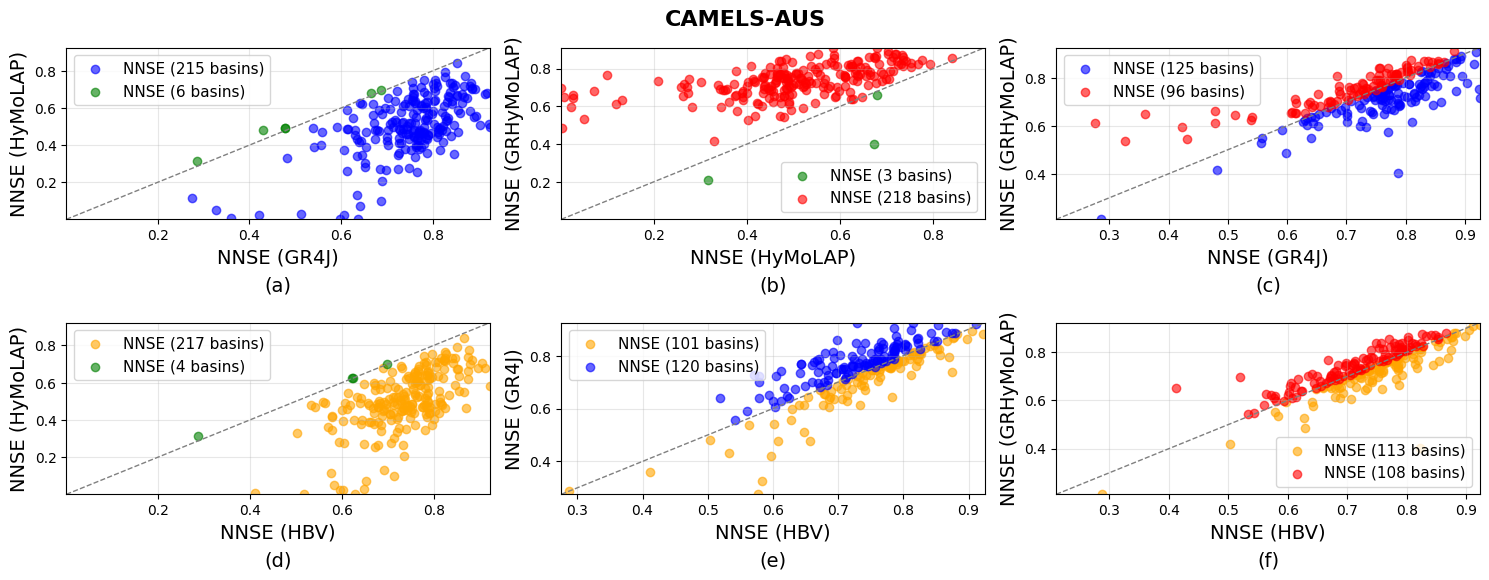

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# 📌NNSE for eachchaque model
# ===============================
def calc_nnse(nse_array):
    return 1 / (2 - nse_array)

GRHyMoLAP_nnse = calc_nnse(GRHyMoLAP)
GR4J_nnse = calc_nnse(GR4J)
HyMoLAP_nnse = calc_nnse(HyMoLAP)
HBV_nnse = calc_nnse(HBV)

# ===============================
# 📌 Couleurs des modèles
# ===============================
colors = {
    'GRHyMoLAP': 'red',
    'GR4J': 'blue',
    'HyMoLAP': 'green',
    'HBV': 'orange'
}

# ===============================
# 📌 Fonction scatter pour NNSE
# ===============================
def scatter_points_nnse(ax, x, y, xlabel_model, ylabel_model, legend_loc='upper left'):
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x = x[mask]
    y = y[mask]

    if len(x) == 0 or len(y) == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center', fontsize=14)
        ax.axis("off")
        return

    above = y > x
    below = ~above

    # Scatter points
    ax.scatter(x[below], y[below], c=colors[xlabel_model], alpha=0.6,
               label=f"NNSE ({below.sum()} basins)")
    ax.scatter(x[above], y[above], c=colors[ylabel_model], alpha=0.6,
               label=f"NNSE ({above.sum()} basins)")

    #  y=x
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, '--', color='gray', linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    # Labels axes
    ax.set_xlabel(f"NNSE ({xlabel_model})", fontsize=14)
    ax.set_ylabel(f"NNSE ({ylabel_model})", fontsize=14)

    #
    ax.legend(loc=legend_loc, fontsize=11)
    ax.grid(True, alpha=0.3)

# ===============================
# 📌 Pairs to compare (2x3 layout)
# ===============================
pairs_ordered = [
    ('GR4J','HyMoLAP'),        # (a)
    ('HyMoLAP','GRHyMoLAP'),   # (b)
    ('GR4J','GRHyMoLAP'),      # (c)
    ('HBV','HyMoLAP'),         # (d)
    ('HBV','GR4J'),            # (e)
    ('HBV','GRHyMoLAP')        # (f)
]

# ===============================
# 📌  légendes
# ===============================
legend_locs = []
for i, (x_model, y_model) in enumerate(pairs_ordered):
    if i == 5:
        legend_locs.append('lower right')  # dernier subplot
    elif x_model == 'HyMoLAP':
        legend_locs.append('lower right')
    elif y_model == 'HyMoLAP':
        legend_locs.append('upper left')
    else:
        legend_locs.append('upper left')

# ===============================
# 📌  figure 2x3
# ===============================
fig, axes = plt.subplots(2,3, figsize=(15,6))
axes = axes.flatten()

# General title
fig.suptitle("CAMELS-AUS", fontsize=16, fontweight='bold', y=0.98)

# Loop
nnse_data = {
    'GRHyMoLAP': GRHyMoLAP_nnse,
    'GR4J': GR4J_nnse,
    'HyMoLAP': HyMoLAP_nnse,
    'HBV': HBV_nnse
}

for i, ((x_model, y_model), loc) in enumerate(zip(pairs_ordered, legend_locs)):
    scatter_points_nnse(
        axes[i],
        nnse_data[x_model],
        nnse_data[y_model],
        x_model,
        y_model,
        legend_loc=loc
    )

# ===============================
# 📌  labels (a-f)
# ===============================
labels = ['(a)','(b)','(c)','(d)','(e)','(f)']
for ax, label in zip(axes, labels):
    ax.text(0.5, -0.33, label, transform=ax.transAxes,
            ha='center', va='top', fontsize=14)

plt.tight_layout()
plt.savefig("NNSE_scatter_CAMELS-AUS.jpeg", dpi=700, format="jpeg")
#files.download("NNSE_scatter_CAMELS-AUS.jpeg")
plt.show()

## Performaance following Runoff Ratio

In [ ]:
# =============================================================
# 📌 Computing RUNOFF RATIO (RR)
# =============================================================
RR = []

for st in common_stations:
    P = precip[st].to_numpy(dtype=float)
    Qs = Q[st].to_numpy(dtype=float)

    mask = (~np.isnan(P)) & (~np.isnan(Qs))

    if mask.sum() == 0 or np.nansum(P[mask]) <= 0:
        RR.append(np.nan)
    else:
        RR.append(np.nansum(Qs[mask]) / np.nansum(P[mask]))

RR = np.array(RR)

print(f"✅ RR computed for {np.sum(~np.isnan(RR))} basins")


✅ RR computed for 222 basins


In [ ]:
# =============================================================
# 📌 Deleting the problematic basin
# =============================================================
basin_to_remove = "803003"

if basin_to_remove in common_stations:
    idx = common_stations.index(basin_to_remove)

    print(f"❌ Basin {basin_to_remove} removed (index {idx})")

    # Remove from stations
    common_stations.pop(idx)

    # Remove from RR and NNSE
    RR = np.delete(RR, idx)
else:
    print("ℹ️ Basin 803003 already absent")


❌ Basin 803003 removed (index 197)


In [ ]:
# =============================================================
# 📌 Final DATAFRAME
# =============================================================
assert len(RR) == len(GR4J) == len(HBV) == len(GRHyMoLAP)

df = pd.DataFrame({
    "RR": RR,
    "GR4J": GR4J,
    "HBV": HBV,
    "GRHyMoLAP": GRHyMoLAP,
    "HyMoLAP": HyMoLAP
}).dropna(subset=["RR"])

print("✅ DataFrame ready:", df.shape)


✅ DataFrame ready: (221, 5)


In [ ]:
# =============================================================
# 📌 CLASSES of RR (10 classes)
# =============================================================
percentiles = np.linspace(0, 100, 11)  # 0,10,20,...,100 → 10 classes
RR_bins = np.percentile(df["RR"], percentiles)
RR_labels = [f"{int(percentiles[i])}–{int(percentiles[i+1])}%" for i in range(len(percentiles)-1)]

df["RR_class"] = pd.cut(
    df["RR"],
    bins=RR_bins,
    labels=RR_labels,
    include_lowest=True
)

print("✅ RR classes created:")
print(df["RR_class"].value_counts().sort_index())


✅ RR classes created:
RR_class
0–10%      23
10–20%     22
20–30%     22
30–40%     22
40–50%     22
50–60%     22
60–70%     22
70–80%     22
80–90%     22
90–100%    22
Name: count, dtype: int64


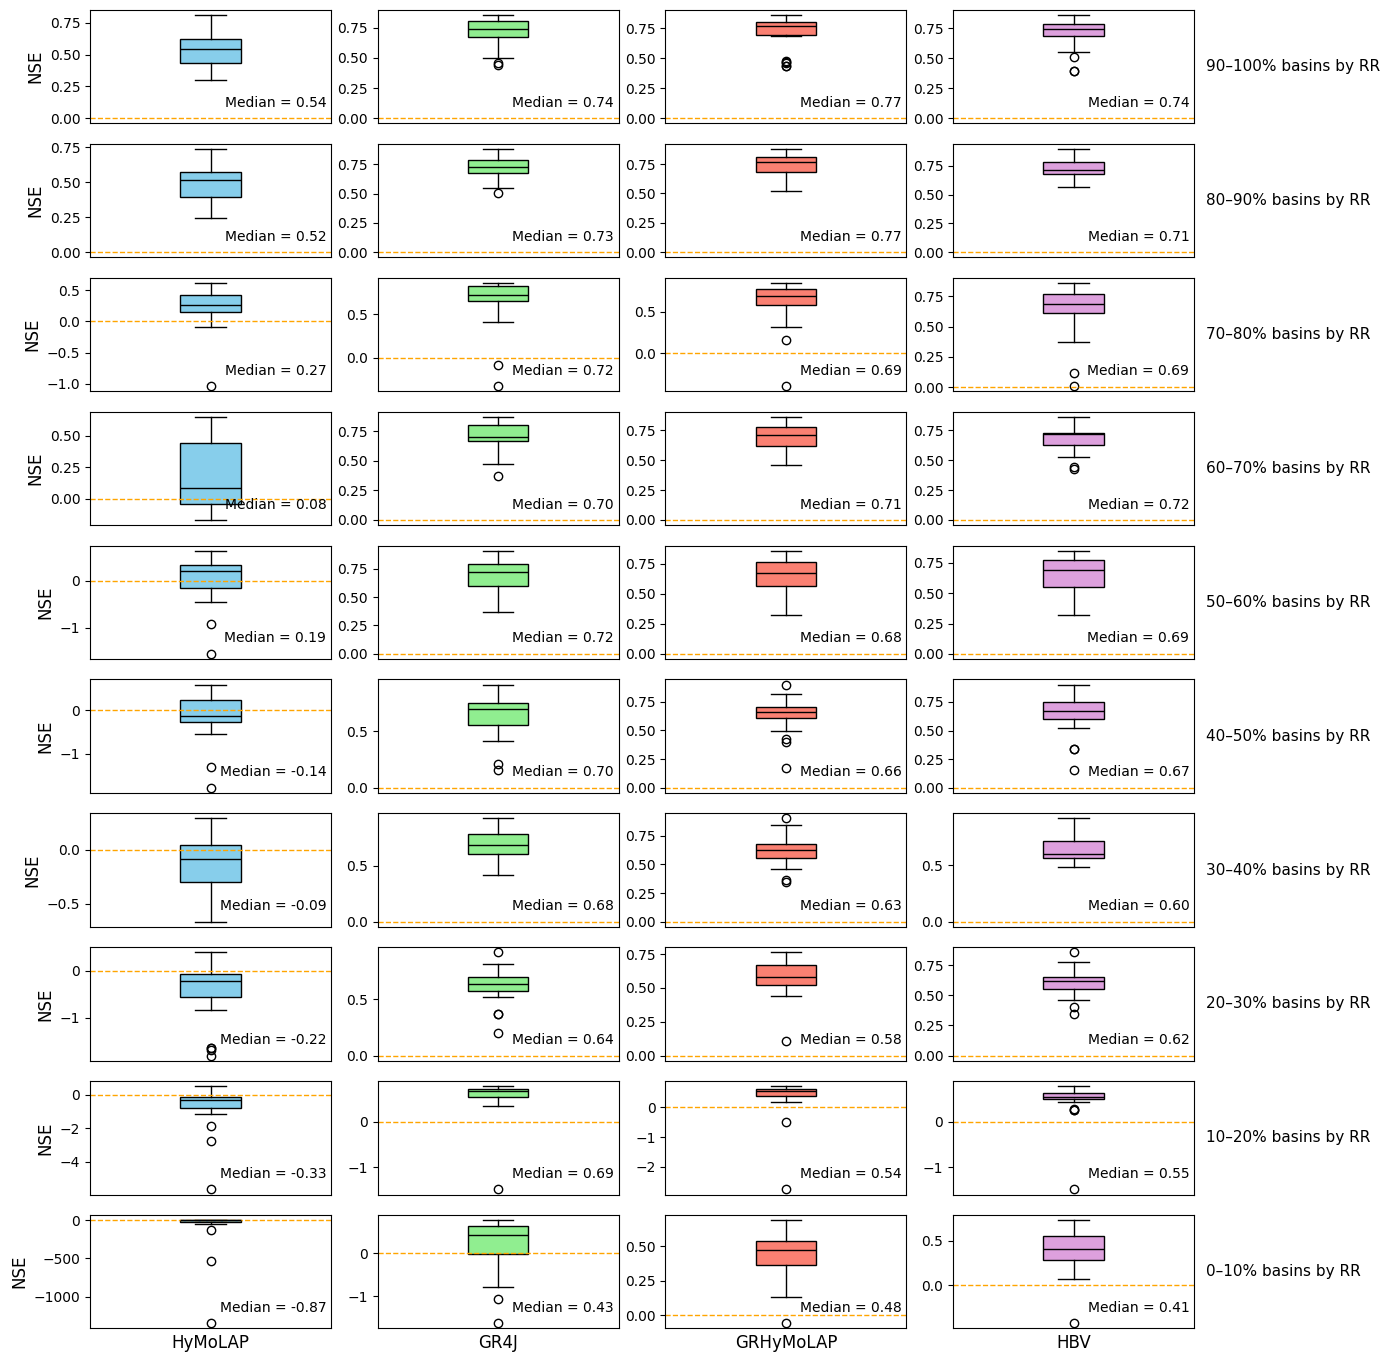

In [ ]:
# =============================================================
# 📌 PARAMETERS
# =============================================================
models = ["HyMoLAP", "GR4J", "GRHyMoLAP", "HBV"]
colors = [ "skyblue", "lightgreen", "salmon", "plum" ]

# Order RR : low → high (0–10, 10–20, ..., 90–100)
RR_classes = [f"{int(x)}–{int(y)}%" for x, y in zip(range(0, 100, 10), range(10, 110, 10))][::-1]

# Size of text
fontsize_axes = 12
fontsize_labels = 11
fontsize_mean = 10

# =============================================================
# 📌 FIGURE 10x4
# =============================================================
fig, axes = plt.subplots(
    nrows=len(RR_classes),
    ncols=len(models),
    figsize=(14, 14),
    sharey=False
)

for i, rr_class in enumerate(RR_classes):
    df_c = df[df["RR_class"] == rr_class]

    for j, model in enumerate(models):
        ax = axes[i, j]
        data = df_c[model].dropna().values

        if len(data) == 0:
            data = [np.nan]

        # =====================
        # Boxplot
        # =====================
        ax.boxplot(
            data,
            patch_artist=True,
            widths=0.25,
            medianprops=dict(color="black"),
            boxprops=dict(facecolor=colors[j], edgecolor="black"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black")
        )

        # Line NSE = 0
        ax.axhline(0, color="orange", linestyle="--", linewidth=1)

        # =====================
        # Median
        # =====================
        if len(data) > 0 and not np.isnan(data).all():
            median_val = np.nanmedian(data)
            ax.text(
                0.98, 0.12,
                f"Median = {median_val:.2f}",
                transform=ax.transAxes,
                fontsize=fontsize_mean,
                ha="right",
                va="bottom"
            )

        # =====================
        # Label RR
        # =====================
        if j == len(models)-1:
            ax.text(
                1.05, 0.5,
                f"{rr_class} basins by RR",
                transform=ax.transAxes,
                fontsize=fontsize_labels,
                ha="left",
                va="center"
            )

        # =====================
        # Label NSE
        # =====================
        if j == 0:
            ax.set_ylabel("NSE", fontsize=fontsize_axes)

        # =====================
        # Model names
        # =====================
        if i == len(RR_classes) - 1:
            ax.set_xlabel(model, fontsize=fontsize_axes)

        ax.set_xticks([])

# =============================================================
# 📌 GLOBAL TITLE
# =============================================================
#fig.suptitle("CAMELS-AUS", fontsize=16, fontweight="bold", y=0.98)

plt.tight_layout(rect=[0,0,1,0.98])

plt.savefig("wetness_10classes_CAMLES-AUS.jpeg", dpi=700, format="jpeg")
#files.download("wetness_10classes_CAMLES-AUS.jpeg")
plt.show()

##Boxplots for all metrics

In [ ]:
# Path to the Excel file stored in Google Drive
file_path1 = "/content/drive/MyDrive/Colab Notebooks/Coupling/Paper1/AUS/Multiple_basins/Model_simulation/HyMoLAP_validation_metrics.xlsx"
file_path2 = "/content/drive/MyDrive/Colab Notebooks/Coupling/Paper1/AUS/Multiple_basins/Model_simulation/GRHyMoLAP_validation_metrics.xlsx"
file_path3 = "/content/drive/MyDrive/Colab Notebooks/Coupling/Paper1/AUS/Multiple_basins/Model_simulation/GR4J_validation_metrics.xlsx"
file_path4 = "/content/drive/MyDrive/Colab Notebooks/Coupling/Paper1/AUS/Multiple_basins/Model_simulation/HBV_validation_metrics.xlsx"

# Read the Excel file (by default it loads the first sheet)
df1 = pd.read_excel(file_path1)
df2 = pd.read_excel(file_path2)
df3 = pd.read_excel(file_path3)
df4 = pd.read_excel(file_path4)

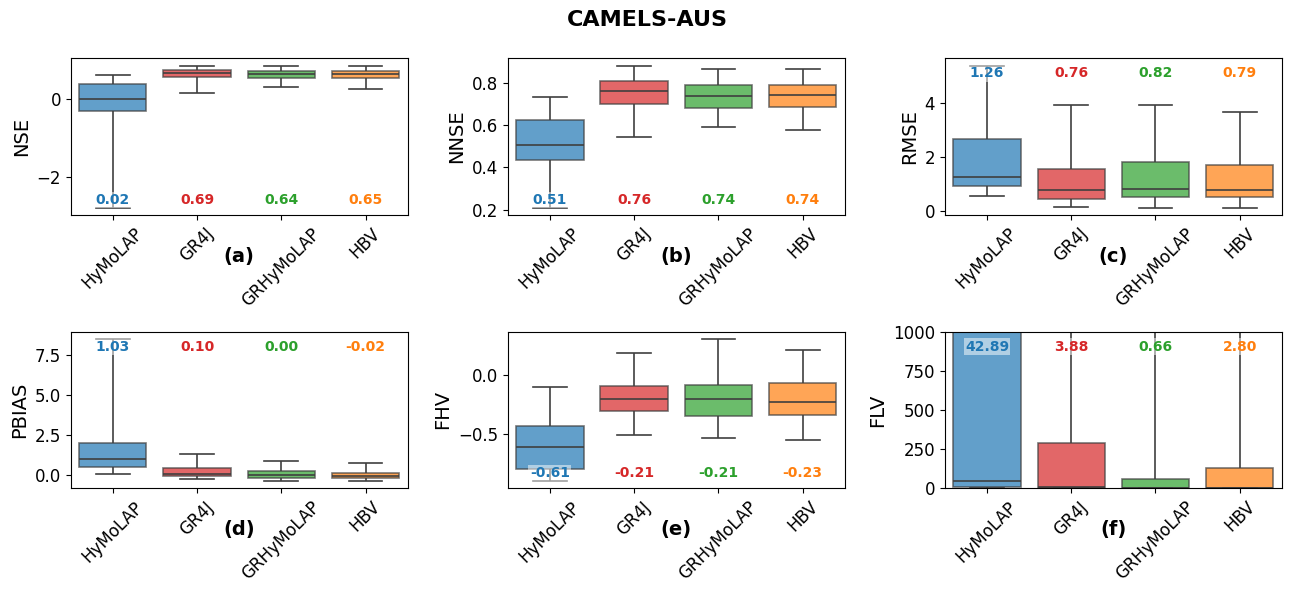

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from google.colab import files

# -------------------------
# Models and dataframe
# -------------------------
models = {
    'HyMoLAP': df1,
    'GR4J': df3,
    'GRHyMoLAP': df2,
    'HBV': df4
}

model_order = ['HyMoLAP','GR4J','GRHyMoLAP','HBV']
colors_list = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']
colors_dict = dict(zip(model_order, colors_list))
bottom_metrics = ['NSE','NNSE','FHV']

#
subplot_labels = ['(a)','(b)','(c)','(d)','(e)','(f)']

# -------------------------
# Metrics
# -------------------------
metrics = ['NSE_val', 'NNSE_val', 'RMSE_val', 'PBIAS_val', 'FHV_val', 'FLV_val']

# -------------------------
# GlobalDataFrame
# -------------------------
dfs = []

for model_name, df_model in models.items():

    df_tmp = df_model.copy()
    df_tmp['Model'] = model_name

    cols_to_keep = [c for c in metrics if c in df_tmp.columns] + ['Model']
    df_tmp = df_tmp[cols_to_keep]

    df_tmp.columns = [c.replace('_val','') for c in df_tmp.columns]

    dfs.append(df_tmp)

df_all = pd.concat(dfs, ignore_index=True)

# -------------------------
# figure
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
axes = axes.flatten()

for i, metric in enumerate([m.replace('_val','') for m in metrics]):

    ax = axes[i]

    valid_models = [m for m in model_order if df_all[df_all['Model']==m][metric].notna().any()]

    if not valid_models:
        ax.text(0.5,0.5,"No data",ha='center',va='center',fontsize=14)
        ax.axis('off')
        continue

    # boxplot
    sns.boxplot(
        x='Model',
        y=metric,
        data=df_all[df_all['Model'].isin(valid_models)],
        order=valid_models,
        whis=[5,95],
        showfliers=False,
        linewidth=1.2,
        ax=ax
    )

    # box
    for patch, model in zip(ax.patches, valid_models):
        patch.set_facecolor(colors_dict[model])
        patch.set_alpha(0.7)

    if metric=='FLV':
        ax.set_ylim(0,1000)

    # axes
    ax.set_xlabel('')
    ax.set_ylabel(metric, fontsize=14)

    ax.tick_params(axis='x', rotation=45, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # médianes
    for j, model in enumerate(model_order):

        vals = df_all[df_all['Model']==model][metric].dropna()

        if len(vals)==0:
            continue

        med_val = np.median(vals)

        x_coord = valid_models.index(model) if model in valid_models else j

        ylim = ax.get_ylim()

        if metric in bottom_metrics:
            y_coord = ylim[0] + 0.05*(ylim[1]-ylim[0])
            va = 'bottom'
        else:
            y_coord = ylim[1] - 0.05*(ylim[1]-ylim[0])
            va = 'top'

        ax.text(
            x_coord,
            y_coord,
            f"{med_val:.2f}",
            fontsize=10,
            ha='center',
            va=va,
            fontweight='bold',
            color=colors_dict[model],
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1)
        )

    # -------------------------
    # lettre subplot (a,b,c,d,e,f)
    # -------------------------
    ax.text(
        0.5,
        -0.30,
        subplot_labels[i],
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        ha='center'
    )

fig.suptitle("CAMELS-AUS", fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0,0,1,0.99])

plt.savefig("boxpplot_AUS.jpeg", dpi=700)

#files.download("boxpplot_AUS.jpeg")

plt.show()